In [31]:
import numpy as np
import pandas as pd

In [17]:
# draw times from two distinct exponential distributions
# and sum them (one 'cycle' consists of 2 consecutive exponential processes)
rate1 = 1
rate2 = 2

cycle_times = []
for i in range(10000):
    time1 = np.random.exponential(rate1, size=1)
    time2 = np.random.exponential(rate2, size=2)
    cycle_time = time1[0] + time2[0]
    cycle_times.append(cycle_time)
    
# the time points of cycle completions in continuous time trace 
time_points = np.cumsum(cycle_times)

# convert to pandas.timedelta
time_deltas = pd.to_timedelta(time_points, unit='s')

In [18]:
# count events every 20 seconds
resample = '20 s'
events = np.ones(len(time_deltas))
series = pd.Series(events, index=time_deltas)
series = series.resample(resample).sum()
time_deltas = series.index
in_seconds = time_deltas / np.timedelta64(1, "s")
series.index = in_seconds

In [19]:
series

1.034009        7.0
21.034009       6.0
41.034009       6.0
61.034009       8.0
81.034009       8.0
               ... 
30021.034009    7.0
30041.034009    6.0
30061.034009    9.0
30081.034009    9.0
30101.034009    6.0
Length: 1506, dtype: float64

In [24]:
# probability of counting e.g., 5 events in 20 seconds
fives = np.where(series == 5)[0]
pr_five = len(fives)/len(series)
print(f'The observed probability of counting 5 cycles (i.e., events) is {pr_five:.3f}')

The observed probability of counting 5 cycles (i.e., events) is 0.139


In [28]:
# defining the proposed mathematical expression
from mpmath import nsum, inf, factorial
from scipy.special import gamma

def phi(b, c, w, z):
    f = b**2/c
    result = float(nsum(lambda k, l: f * w**k * z**l / (factorial(l)*factorial(k)), [0, inf], [0, inf]))

    return result


def c_x(t, a, b, x):
    part1 = (a * b)**x
    part2 = t**(2*x)/gamma(1+2*x)
    part3 = phi(x, 1+2*x, -t*a, -t*b)
    func = part1 * part2 * part3

    return func


def counts_hypo_interarrival_times_pmf(t, a, b, x):
    pmf = c_x(t, a, b, x) - c_x(t, a, b, x+1)

    return pmf

In [29]:
# inserting the values into the proposed mathematical expression
t = 20
a = 1
b = 2
x = 5
counts_hypo_interarrival_times_pmf(t, a, b, x)

-1.1473533046143436e-17

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import poisson, norm
import matplotlib.pyplot as plt
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")
import src.distributions as d
import src.fluorophore_systems as fs
import src.figures as fi

%load_ext autoreload
%autoreload 2

In [4]:
rate_dict = dict(k_S0_S1=[1, "excitation"],
                 k_S1_S0=[2, "emission"])
system = fs.GeneralModel(number=1,  distances=1, rates=rate_dict)
system.simulate(n_steps=10000000, seed=99)
system.process()
system.emitters(resample="10s", photon_collection=1)

### Description via PMF stated in financial paper does not work:

In [112]:
ones = np.where(system.pandas_series == 1)[0]
probability_observed_1 = len(ones)/len(system.pandas_series)
twos = np.where(system.pandas_series == 2)[0]
probability_observed_2 = len(twos)/len(system.pandas_series)
t, a, b, x = 10, 2, 1, 1
probability_calc_1 = d.counts_hypo_interarrival_times_pmf(t, a, b, x)
t, a, b, x = 10, 2, 1, 2
probability_calc_2 = d.counts_hypo_interarrival_times_pmf(t, a, b, x)
print(f'{probability_observed_1},{probability_calc_1}')
print(f'{probability_observed_2},{probability_calc_2}')

0.0010834106086179177,-1.2164909859492228e-10
0.007910765392236003,-1.21203497501168e-09


### Approximation with normal distribution works

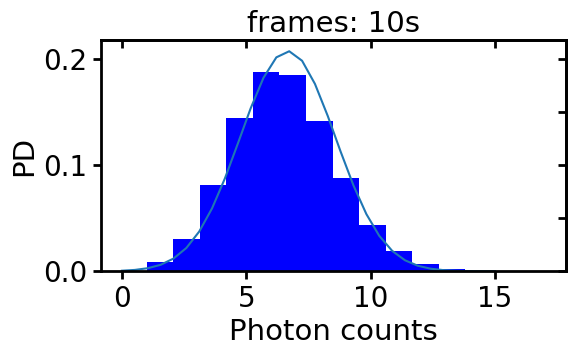

In [113]:
x = np.linspace(0, 15, 30)
mean_hypo = 1/(1) + 1/(2)
var_hypo = 1/(1)**2 + 1/(2)**2
t = 10
mean_norm = t/mean_hypo
std_norm = np.sqrt(var_hypo) * np.sqrt(t) / mean_hypo**(3/2)
normal = norm.pdf(x, mean_norm, std_norm)

fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=15)
ax[0].plot(x, normal)

## Combination of two count distributions possible?

In [52]:
steps = 100000
random_numbers = np.random.uniform(0, 1, steps)
times = np.ones(steps)
times1 = []
times2 = []

for i in range(steps):
    if random_numbers[i]>0.3:
        interarrival_time = np.random.exponential(1/10, size=1)
        times[i] = interarrival_time
        times1.append(interarrival_time)
    else:
        interarrival_time = np.random.exponential(1/1, size=1)
        times[i] = interarrival_time
        times2.append(interarrival_time)


In [54]:
def process(times, resample):    
    time_points = np.cumsum(times)
    time_points = np.insert(time_points, 0, 0)
    time_deltas = pd.to_timedelta(time_points, unit="s")

    events = np.ones(len(time_points))
    events[0] = 0 
    series = pd.Series(events, index=time_deltas)
    series = series.resample(resample).sum()
    time_deltas = series.index
    in_seconds = time_deltas / np.timedelta64(1, "s")
    series.index = in_seconds
    
    return series

In [56]:
merged = process(times, "10s")
t1 = process(times1, "10s")
t2 = process(times2, "10s")

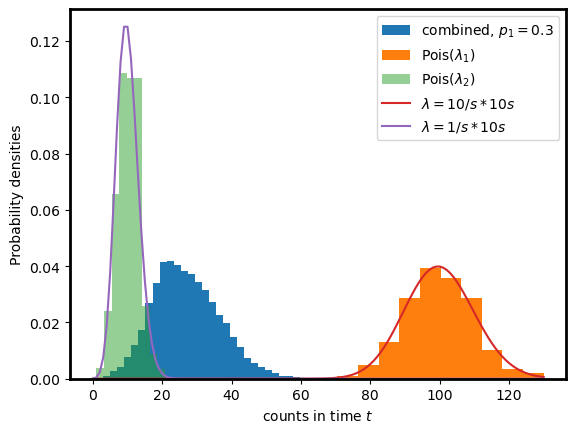

In [119]:
x = np.linspace(0, 130, 131)
plt.hist(merged, bins=34, label='combined, $p_1 = 0.3$', density=True);
plt.hist(t1, bins=20, label='Pois($\lambda_1$)', density=True)
plt.hist(t2, bins=10, label='Pois($\lambda_2$)', density=True, alpha=0.5)
plt.ylabel('Probability densities')
plt.xlabel('counts in time $t$')
plt.plot(x, poisson.pmf(x, 10*10), label='$\lambda = 10/s*10s$')
plt.plot(x, poisson.pmf(x, 1*10), label='$\lambda = 1/s*10s$')
plt.legend()